In [1]:
import torch
import torch.nn as nn
import numpy as np
from DDBSCAN import Raster_DBSCAN
from torch.utils.data import Dataset,DataLoader
import torch.optim as optim
from Models import *
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.colors as mcolors
from ModelSocial import LaneOccupancySocialLSTM
from TrainSocialLSTM import extract_trajectories,prepare_training_data
# times new roman font
plt.rcParams["font.family"] = "Times New Roman"
seed = 414
# np.random.seed(seed)
colors = np.random.rand(600, 3)
colors = np.concatenate([np.array([[0,0,0]]),colors],axis = 0)
colormap = mcolors.ListedColormap(colors)

In [ ]:
class ImprovedSocialLSTM(nn.Module):
    def __init__(self, 
                 hidden_size=64,         # LSTM hidden state size
                 social_size=32,         # Social context embedding size
                 input_frames=10,        # Number of input frames 
                 output_size=1,          # Number of outputs (typically just the next position)
                 dropout=0.2,            # Dropout probability
                 use_cuda=True):         # GPU acceleration
        """
        Improved Social LSTM with better handling of missing neighbors
        """
        super(ImprovedSocialLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.social_size = social_size
        self.input_frames = input_frames
        self.output_size = output_size
        self.use_cuda = use_cuda and torch.cuda.is_available()
        
        # Position embedding
        self.position_embedding = nn.Linear(1, hidden_size)
        
        # Social context embeddings with explicit presence flags
        self.front_vehicle_embedding = nn.Linear(2, social_size)  # [distance, presence_flag]
        self.back_vehicle_embedding = nn.Linear(2, social_size)   # [distance, presence_flag]
        
        # Combine social embeddings into context
        self.social_context_combine = nn.Linear(2 * social_size, hidden_size)
        
        # LSTM for sequence processing
        self.lstm = nn.LSTM(
            input_size=2 * hidden_size,  # Position embedding + social context
            hidden_size=hidden_size,
            batch_first=True,
            dropout=dropout if input_frames > 1 else 0
        )
        
        # Output layer
        self.output_layer = nn.Linear(hidden_size, output_size)
        
        # Activation
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, inputs):
        """
        Forward pass for the Improved Social LSTM
        
        Args:
            inputs: Input tensor structure [batch_size, input_frames, 5]
                inputs[:,:,0] = tracked vehicle position
                inputs[:,:,1] = distance to front vehicle (0 if none)
                inputs[:,:,2] = front vehicle presence flag (0 or 1)
                inputs[:,:,3] = distance to back vehicle (0 if none)
                inputs[:,:,4] = back vehicle presence flag (0 or 1)
            
        Returns:
            outputs: Predicted next position [batch_size, output_size]
        """
        batch_size = inputs.size(0)
        seq_length = inputs.size(1)
        
        # Prepare output tensor
        lstm_inputs = torch.zeros(batch_size, seq_length, 2 * self.hidden_size)
        if self.use_cuda:
            lstm_inputs = lstm_inputs.cuda()
        
        # Process each time step to create embeddings
        for t in range(seq_length):
            # Extract data for current time step
            pos = inputs[:, t, 0].unsqueeze(1)  # [batch, 1]
            
            front_data = inputs[:, t, 1:3]      # [batch, 2] - [distance, presence]
            back_data = inputs[:, t, 3:5]       # [batch, 2] - [distance, presence]
            
            # Embed position
            pos_embedded = self.dropout(self.relu(self.position_embedding(pos)))
            
            # Embed social context with presence flags
            front_embedded = self.dropout(self.relu(self.front_vehicle_embedding(front_data)))
            back_embedded = self.dropout(self.relu(self.back_vehicle_embedding(back_data)))
            
            # Combine social context
            social_context = torch.cat((front_embedded, back_embedded), dim=1)
            social_embedded = self.dropout(self.relu(self.social_context_combine(social_context)))
            
            # Combine all features
            lstm_inputs[:, t] = torch.cat((pos_embedded, social_embedded), dim=1)
        
        # Process through LSTM
        lstm_out, (h_n, _) = self.lstm(lstm_inputs)
        
        # Predict output using final hidden state
        output = self.output_layer(h_n[-1])
        
        return output

In [ ]:
def prepare_numerical_data(traffic_context, batch_size=4):
    """
    Prepare numerical data from traffic context for the simplified model
    
    Args:
        traffic_context: Occupancy grid [batch, lane_cell_num, seq_length]
                         Each element is trajectory ID (0 = unoccupied)
        batch_size: Desired batch size
        
    Returns:
        inputs: Input tensor [batch_size, input_frames, 3]
        targets: Target positions [batch_size, output_size]
    """
    batch = traffic_context.size(0)
    lane_cells = traffic_context.size(1)
    seq_length = traffic_context.size(2)
    
    # Set parameters
    input_frames = 10
    window_size = input_frames + 1  # +1 for target
    
    inputs_list = []
    targets_list = []
    
    # Process each scenario in the batch
    for b in range(batch):
        # Find unique vehicle IDs
        unique_ids = torch.unique(traffic_context[b])
        unique_ids = unique_ids[unique_ids > 0]
        
        # Process each vehicle trajectory
        for vehicle_id in unique_ids:
            # Find positions of this vehicle at each time step
            positions = []
            for t in range(seq_length):
                # Find cells occupied by this vehicle
                cells = torch.nonzero(traffic_context[b, :, t] == vehicle_id, as_tuple=True)[0]
                if len(cells) > 0:
                    positions.append(cells[0].item())
                else:
                    positions.append(-1)
            
            # Create sliding windows
            for start_idx in range(seq_length - window_size + 1):
                window = positions[start_idx:start_idx + window_size]
                
                # Skip windows with missing positions
                if -1 in window:
                    continue
                
                # Extract input and target positions
                input_positions = window[:input_frames]
                target_position = window[input_frames]
                
                # Create input tensor with [position, front_dist, back_dist]
                input_data = torch.zeros(input_frames, 3)
                
                for t, pos in enumerate(input_positions):
                    # Set tracked vehicle position
                    input_data[t, 0] = pos
                    
                    # Find front vehicle
                    front_dist = 999
                    for front_pos in range(pos + 1, lane_cells):
                        curr_id = traffic_context[b, front_pos, start_idx + t]
                        if curr_id > 0 and curr_id != vehicle_id:
                            front_dist = front_pos - pos
                            break
                    
                    # Find back vehicle
                    back_dist = -999
                    for back_pos in range(pos - 1, -1, -1):
                        curr_id = traffic_context[b, back_pos, start_idx + t]
                        if curr_id > 0 and curr_id != vehicle_id:
                            back_dist = back_pos - pos  # Will be negative
                            break
                    input_data[t, 1] = - back_dist  # turn to positive distance
                    input_data[t, 2] = front_dist # this is acutally the back distance, because the front is the stop bar, so it is negative

                
                inputs_list.append(input_data)
                targets_list.append(torch.tensor([target_position]))
                
                # If we have enough samples for a batch, yield them
                if len(inputs_list) >= batch_size:
                    inputs_batch = torch.stack(inputs_list[:batch_size])
                    targets_batch = torch.stack(targets_list[:batch_size])
                    
                    inputs_list = inputs_list[batch_size:]
                    targets_list = targets_list[batch_size:]
                    
                    yield inputs_batch, targets_batch
    
    # Yield any remaining samples
    if len(inputs_list) > 0:
        inputs_batch = torch.stack(inputs_list)
        targets_batch = torch.stack(targets_list)
        yield inputs_batch, targets_batch

In [51]:
from collections import defaultdict
def get_trajctories_dict_from_Label_map(Labels,time_span,center = True):
    trajectories_output = defaultdict(list)
    for t in range(time_span):
        Labels_t = Labels[:,t]
        unique_id, xs, counts = np.unique(Labels_t,return_index=True,return_counts=True)
        if center:
            center_locations = xs + 0.5*counts
        else:
            center_locations = xs
        if unique_id[0] == -1:
            unique_id = unique_id[1:]
            center_locations = center_locations[1:]
        for i, label in enumerate(unique_id):
            trajectories_output[label].append((t,center_locations[i]))
    for key in trajectories_output.keys():
        traj = trajectories_output[key]
        trajectories_output[key] = np.array(traj)
    return trajectories_output

In [73]:
import h5py
out_folder = r"D:\TimeSpaceDiagramDataset\SocialLSTMDataset"
val_folder = os.path.join(out_folder,"val")
os.makedirs(val_folder,exist_ok=True)
train_folder = os.path.join(out_folder,"train")
os.makedirs(train_folder,exist_ok=True)
train_count = 40000
val_count = 7000
batch_size = 4
time_span = 100
val_dataset = TrajDataset(r"D:\TimeSpaceDiagramDataset\EncoderDecoder_EvenlySampled_FreeflowAug_0914_5res_lanechange_signal\100_frame\val",time_span)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True, num_workers=1)
# find out the number of 1 over the total number of elements
counts = 0
h5_file = h5py.File(os.path.join(val_folder,"val_dataset.h5"),'w')
for batch_idx,batch in enumerate(tqdm(val_loader)):
    traj_id = batch['traj_id']
    gen = prepare_numerical_data(traj_id)
    # Create a group for this batch
    batch_group = h5_file.create_group(f'batch_{batch_idx}')
    batch_count = 0
    while True:
        try:
            inputs, targets = next(gen)
            mini_batch = batch_group.create_group(f'mini_batch_{batch_count}')
            mini_batch.create_dataset('inputs', data=inputs.numpy(), compression="gzip")
            mini_batch.create_dataset('targets', data=targets.numpy(), compression="gzip")
            counts += inputs.size(0)
            batch_count += 1
        except StopIteration:
            break
    batch_group.attrs['total_samples'] = batch_count
    if counts > val_count:
        break
h5_file.attrs['total_trajectory_samples'] = counts
h5_file.close()

train_dataset = TrajDataset(r"D:\TimeSpaceDiagramDataset\EncoderDecoder_EvenlySampled_FreeflowAug_0914_5res_lanechange_signal\100_frame\train",time_span)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=1)
# find out the number of 1 over the total number of elements
counts = 0
h5_file = h5py.File(os.path.join(train_folder,"train_dataset.h5"),'w')
for batch_idx,batch in enumerate(tqdm(train_loader)):
    traj_id = batch['traj_id']
    gen = prepare_numerical_data(traj_id)
    # Create a group for this batch
    batch_group = h5_file.create_group(f'batch_{batch_idx}')
    batch_count = 0
    while True:
        try:
            inputs, targets = next(gen)
            mini_batch = batch_group.create_group(f'mini_batch_{batch_count}')
            mini_batch.create_dataset('inputs', data=inputs.numpy(), compression="gzip")
            mini_batch.create_dataset('targets', data=targets.numpy(), compression="gzip")
            counts += inputs.size(0)
            batch_count += 1
        except StopIteration:
            break
    batch_group.attrs['total_samples'] = batch_count
    if counts > train_count:
        break
h5_file.attrs['total_trajectory_samples'] = counts
h5_file.close()



  0%|          | 37/246000 [04:54<543:00:06,  7.95s/it]


In [52]:
gen = prepare_numerical_data(traj_id.cpu())

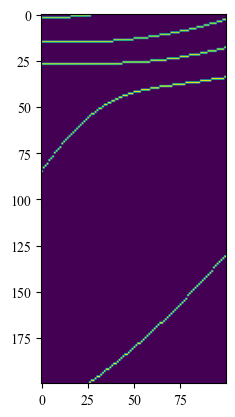

In [41]:
plt.imshow(traj_id.cpu().numpy()[1])
plt.show()

In [3]:
from Dataset import TrajectoryDataset

In [11]:
targets

tensor([[131.],
        [ 24.],
        [  0.],
        [175.],
        [ 23.],
        [ 15.],
        [ 39.],
        [ 66.],
        [ 39.],
        [ 16.],
        [ 13.],
        [145.],
        [ 61.],
        [148.],
        [148.],
        [ 43.],
        [ 94.],
        [193.],
        [ 64.],
        [ 33.],
        [ 85.],
        [  1.],
        [128.],
        [ 23.],
        [ 11.],
        [ 33.],
        [106.],
        [ 97.],
        [ 12.],
        [ 53.],
        [100.],
        [100.]])

In [16]:
inputs[4]

tensor([[ 27.,  19., -19.],
        [ 27.,  19., -19.],
        [ 26.,  19., -18.],
        [ 26.,  19., -19.],
        [ 26.,  19., -19.],
        [ 25.,  20., -19.],
        [ 25.,  20., -19.],
        [ 25.,  19., -20.],
        [ 24.,  20., -19.],
        [ 24.,  20., -20.]])

In [5]:
# Create dataset
dataset = TrajectoryDataset(r'D:\TimeSpaceDiagramDataset\SocialLSTMDataset\train\train_dataset.h5')
print(f"Total samples: {len(dataset)}")

# Create data loader
dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4
)

# Training loop
for batch in dataloader:
    inputs = batch['inputs']
    targets = batch['targets']
    break

Total samples: 40534
